In [72]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [73]:
from nn import Unet1D, Returns, RMSELoss
import torch
from torch.utils.data import DataLoader
from scripts import evaluate
import math
import yfinance as yf
from utils import log_transform, posterior_beta, create_dir, inverse_standard, one_step_forecast
import matplotlib.pyplot as plt
from diffusion import forward, reverse
from arch.univariate import arch_model
import joblib
from datetime import date

In [74]:
ticker = "^GSPC"
start_interval = "2016-12-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()

split = math.ceil(len(raw_snp500) * 0.15)
val_split = len(raw_snp500) - math.ceil(len(raw_snp500) * 0.15) * 2
test_split = len(raw_snp500) - math.ceil(len(raw_snp500) * 0.15)
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 32

train_data = Returns(
  raw_returns=torch.tensor(train_raw_snp500),
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=torch.tensor(val_raw_snp500),
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=torch.tensor(test_raw_snp500),
  window_size=window_size,
  transform=log_transform,
  standard=True
)

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

In [75]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)
loss_fn = RMSELoss()

In [76]:
SAVE_PATH = dir / "models" / "model_v0.pth"
SAVE_PATH.exists()

True

In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [78]:
checkpoint = torch.load(SAVE_PATH, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [79]:
test_result = evaluate(
  data=test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)

test_result

0.5761595765749613

In [80]:
test_sample = next(iter(test_dataloader))

In [81]:
# quick sanity check
T = 1000
batch_size = 32

t = torch.randint(0, T, size=(batch_size,))
xt, _ = forward(test_sample, alpha_hats, t)

epsilon_theta = model(xt, t)
epsilon_theta.mean(), epsilon_theta.std()

(tensor(-0.0180, grad_fn=<MeanBackward0>),
 tensor(0.7624, grad_fn=<StdBackward0>))

In [82]:
# reverse process
xT = torch.randn(size=(32, 1, 32))
posterior_betas = torch.tensor([posterior_beta(alpha_hats=alpha_hats, betas=betas, t=t) for t in range(T)])

In [83]:
generated_samples = []
samples = 1
for _ in range(samples):
  sample = reverse(
    xT=xT,
    T=T,
    betas=betas,
    posterior_betas=posterior_betas,
    alpha_bars=alpha_hats,
    model=model
  )
  generated_samples.append(sample)

In [84]:
generated_samples = [sample.squeeze(1) for sample in generated_samples]
generated_samples[0].size()

torch.Size([32, 32])

In [85]:
# generated_samples = torch.cat(tuple(generated_samples), dim=1)
# generated_samples.size()

In [86]:
flatten_generated_samples = generated_samples[0].flatten(0, 1)
flatten_generated_samples.size()

torch.Size([1024])

In [87]:
flatten_generated_samples = flatten_generated_samples.detach().numpy()
type(flatten_generated_samples)

numpy.ndarray

In [88]:
empirical_data = log_transform(train_raw_snp500)

In [89]:
flatten_generated_samples_inversed = inverse_standard(flatten_generated_samples, empirical_data)

In [90]:
# scaling
flatten_generated_samples_inversed *= 100

In [91]:
"""
  We cant set this as a valid time series, since its generated on independent windows
  and concatenated into a single pseudo time series.
  But this could be our baseline for further improvements.
"""
len(flatten_generated_samples_inversed)

1024

### Baseline evaluation

Since DDPM is trained on windowed overlapping returns and generated iid windowed daily returns,
we cant really compare concatenated (32, 1, 32) into a long series (32*32,) and compare to the empirical
returns. Empirical long series data exhibits autocorrelation in the series, while synthetic data lacks consistent temporal dependence across windows but could exhibit autocorrelation within window

We could see that GARCH failed to remove the autocorrelation within the squared residuals when fitted on concatenated long series synthetic data since concatenation into a long pseudo time series breaks the temporal dependence across windows and to speak fairly there isnt any autocorellation between windows since its a generated iid samples. The plot shows
that diffusion std behaves more like a constant which is incosistent with real-world financial data.

We could compare it against windowed data instead of comparing a long series. The evaluation comparison would be done by comparing volatility clustering within fixed-lenght local segments instead of a long series.

Also since this thesis focus heavily on the unconditional diffusion process, we accept the results as it is and leave further improvements on this topic for conditional diffusion processes for windowed data.

In [96]:
start_test = "2026-01-02"
end_test = str(date.today())
raw_test_data = yf.Ticker(ticker).history(start=start_test, end=end_test, interval="1d")["Close"]

train_samples_raw = train_raw_snp500[:1024]

log_train_samples = log_transform(train_samples_raw) * 100 # scaling
log_test_data = log_transform(raw_test_data.to_numpy()) * 100 # scaling

diff_preds = one_step_forecast(flatten_generated_samples, log_test_data)
empirical_preds = one_step_forecast(log_train_samples, log_test_data)
squared_returns = log_test_data**2

len(diff_preds), len(empirical_preds), len(squared_returns), len(log_test_data)

(60, 60, 60, 60)

In [97]:
log_test_data[0:10]

array([ 0.63340245,  0.6177592 , -0.34458536,  0.00765453,  0.64546111,
        0.15763901, -0.19410056, -0.53476336,  0.25766039, -0.06425087])

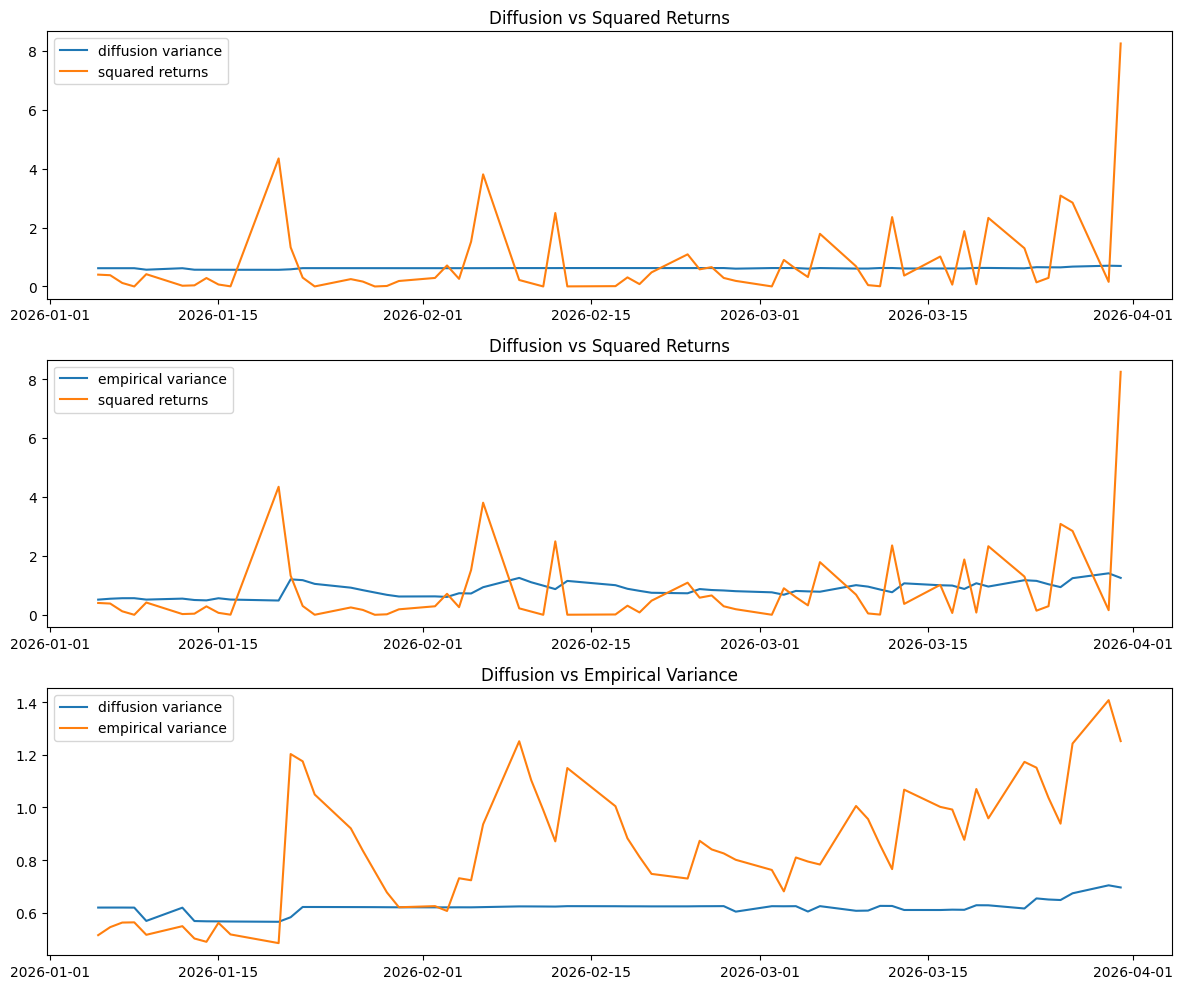

In [98]:
fig, ax = plt.subplots(nrows=3, figsize=(12, 10))
ax[0].plot(raw_test_data.index[1:].date, diff_preds, label="diffusion variance")
ax[0].plot(raw_test_data.index[1:].date, squared_returns, label="squared returns")
ax[0].set_title("Diffusion vs Squared Returns")
ax[0].legend()

ax[1].plot(raw_test_data.index[1:].date, empirical_preds, label="empirical variance")
ax[1].plot(raw_test_data.index[1:].date, squared_returns, label="squared returns")
ax[1].set_title("Diffusion vs Squared Returns")
ax[1].legend()

ax[2].plot(raw_test_data.index[1:].date, diff_preds, label="diffusion variance")
ax[2].plot(raw_test_data.index[1:].date, empirical_preds, label="empirical variance")
ax[2].set_title("Diffusion vs Empirical Variance")
ax[2].legend()

fig.tight_layout()
plt.show()

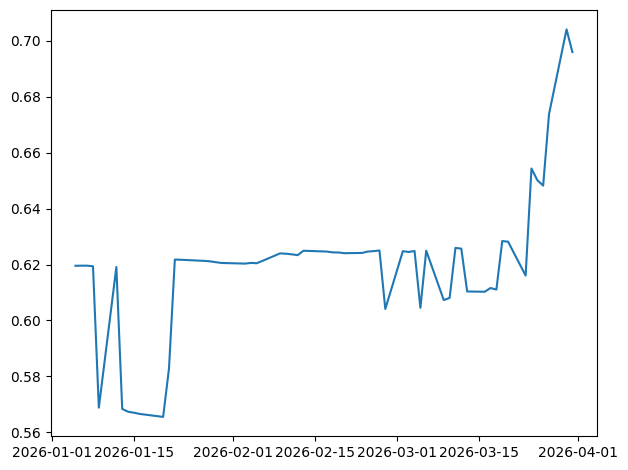

In [100]:
plt.plot(raw_test_data.index[1:].date, diff_preds)
plt.tight_layout()
plt.show()